# Fair Lending Project - Seattle University

Data Preparation and Cleaning - Census Annual Business Survey (ABS) And FRED Economic Data

## Import Libraries


In [1]:
import requests
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
from io import BytesIO

## Prepare environment

In [2]:
# Ensure data directories exists
os.makedirs('../data', exist_ok=True)
os.makedirs('../data/raw', exist_ok=True)

CENSUS_API_KEY = "c162f3620fb054f8b97d67a3ef165e8a8417a185"
db_census_path = '../data/sba_census.db'

# Census API endpoints for SBA data
census2002_url = 'https://www.dropbox.com/scl/fi/grh4qjnxn4nncdz0tv5j7/census_2002_sba.csv?rlkey=q43vc3ijjrdu6ffp0zgjgi7tk&st=8vf1tted&dl=1'
census2007_url = 'https://www.dropbox.com/scl/fi/6lw0l0gmzddcnvn0v6ebc/census_2007_sba.csv?rlkey=coiqvmv8i91z0lbhynk1aornr&st=iahz4mnu&dl=1'

census_NAICS_map_12_07 = 'https://www.census.gov/naics/concordances/2012_to_2007_NAICS.xls'
census_NAICS_map_07_02 = 'https://www.census.gov/naics/concordances/2007_to_2002_NAICS.xls'

# Census local files paths
census2002_path = os.path.join('../data/raw', 'census_2002_sba.csv')
census2007_path = os.path.join('../data/raw', 'census_2007_sba.csv')
census2012_path = os.path.join('../data/raw', 'census_2012_sba.csv')

FRED_API_KEY = "175c981a568a2ea162c4d2a03cf1209c"

series_ids = ["FEDFUNDS", "MPRIME", "CPIAUCSL", "UNRATE"]
base_url = "https://api.stlouisfed.org/fred/series/observations"

fred_path = os.path.join('../data/raw', 'fred_1987_2014.csv')
db_fred_path = '../data/fred_indicators.db'

## Get Census Data

Download census data for 2002 and 2007 from dropbox location. Use Census API to load 2012 data, and download NAICS mapping files between 2002, 2007, and 2012 to later standardize it to NAICS 2012 classification.

In [3]:


# Census API endpoints for SBA data
census2002_url = 'https://www.dropbox.com/scl/fi/grh4qjnxn4nncdz0tv5j7/census_2002_sba.csv?rlkey=q43vc3ijjrdu6ffp0zgjgi7tk&st=8vf1tted&dl=1'
census2007_url = 'https://www.dropbox.com/scl/fi/6lw0l0gmzddcnvn0v6ebc/census_2007_sba.csv?rlkey=coiqvmv8i91z0lbhynk1aornr&st=iahz4mnu&dl=1'

census_NAICS_map_12_07 = 'https://www.census.gov/naics/concordances/2012_to_2007_NAICS.xls'
census_NAICS_map_07_02 = 'https://www.census.gov/naics/concordances/2007_to_2002_NAICS.xls'

# Census local files paths
census2002_path = os.path.join('../data/raw', 'census_2002_sba.csv')
census2007_path = os.path.join('../data/raw', 'census_2007_sba.csv')
census2012_path = os.path.join('../data/raw', 'census_2012_sba.csv')


#Cache data locally if not already present
if not os.path.exists(census2002_path):
    print("Downloading census_2002_sba.csv ...")
    response = requests.get(census2002_url)
    response.raise_for_status()
    with open(census2002_path, 'wb') as f:
        f.write(response.content)
    print("Downloaded census_2002_sba.csv")
else:
    print("census_2002_sba.csv already exists.")

if not os.path.exists(census2007_path):
    print("Downloading census_2007_sba.csv ...")
    response = requests.get(census2007_url)
    response.raise_for_status()
    with open(census2007_path, 'wb') as f:
        f.write(response.content)
    print("Downloaded census_2007_sba.csv.")
else:
    print("census_2007_sba.csv already exists.")

if not os.path.exists(census2012_path):
    print("Fetching SBA Census data for 2012 from https://api.census.gov/data/2012/sbo/cs (10-20 min process) ...")
    url_2012 = "https://api.census.gov/data/2012/sbo/cs"
    vars_2012 = "NAME,NAICS2012,NAICS2012_LABEL,SEX,SEX_LABEL,ETH_GROUP,ETH_GROUP_LABEL,RACE_GROUP,RACE_GROUP_LABEL,VET_GROUP,VET_GROUP_LABEL,FIRMALL,RCPALL,EMP"
    params_2012 = {"get": vars_2012, "for": "state:*"}
    params_2012["key"] = CENSUS_API_KEY
    response_2012 = requests.get(url_2012, params=params_2012)
    response_2012.raise_for_status()
    data_2012 = response_2012.json()
    df_2012 = pd.DataFrame(data_2012[1:], columns=data_2012[0])
    df_2012['YEAR'] = 2012
    df_2012.to_csv(census2012_path, index=False)
    print("Downloaded census_2012_sba.csv.")
else:
    print("census_2012_sba.csv already exists.")


census_2002_sba.csv already exists.
census_2007_sba.csv already exists.
census_2012_sba.csv already exists.


## Load FRED data

In [4]:
all_series_df = []

for series_id in series_ids:
    params = {
        "series_id": series_id,
        "api_key": FRED_API_KEY,
        "file_type": "json",
        "frequency": "m",
        "observation_start": "1987-01-01",
        "observation_end": "2014-12-31"
    }

    response = requests.get(base_url, params=params)
    response.raise_for_status()
    data = response.json()

    df = pd.DataFrame(data["observations"])[["date", "value"]]
    df.rename(columns={"value": series_id}, inplace=True)

    all_series_df.append(df)

merged_df = all_series_df[0]
for series_df in all_series_df[1:]:
    merged_df = pd.merge(merged_df, series_df, on="date", how="outer")

merged_df.to_csv(fred_path, index=False)
print("\nData saved to fred_1987_2014.csv")


Data saved to fred_1987_2014.csv


## Initial Data Analysis

### Census Initial Data Analysis

In [5]:
pd.set_option('display.max_columns', None)

data_dir = '../data/raw'

# Load census data
census_2002_df = pd.read_csv(os.path.join(data_dir, 'census_2002_sba.csv'))
census_2007_df = pd.read_csv(os.path.join(data_dir, 'census_2007_sba.csv'))
census_2012_df = pd.read_csv(os.path.join(data_dir, 'census_2012_sba.csv'))

# Basic EDA for each DataFrame (no loops)
print("\n--- CENSUS 2002 ---")
print(census_2002_df.info())
print(census_2002_df.head())

print("\n--- CENSUS 2007 ---")
print(census_2007_df.info())
print(census_2007_df.head())

print("\n--- CENSUS 2012 ---")
print(census_2012_df.info())
print(census_2012_df.head())

C:\Users\Jack\AppData\Local\Temp\ipykernel_47240\123773351.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  census_2012_df = pd.read_csv(os.path.join(data_dir, 'census_2012_sba.csv'))



--- CENSUS 2002 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24024 entries, 0 to 24023
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   YEAR                24024 non-null  int64 
 1   GEOGRAPHY           24024 non-null  object
 2   NAICS2002           24024 non-null  object
 3   NAICS2002_MEANING   24024 non-null  object
 4   SEX                 24024 non-null  int64 
 5   SEX_MEANING         24024 non-null  object
 6   RACE_GROUP          24024 non-null  int64 
 7   RACE_GROUP_MEANING  24024 non-null  object
 8   FIRMALL             24024 non-null  int64 
 9   RCPALL              24024 non-null  int64 
 10  EMP                 24024 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 2.0+ MB
None
   YEAR      GEOGRAPHY NAICS2002      NAICS2002_MEANING  SEX  \
0  2002  United States        00  Total for all sectors    0   
1  2002  United States        00  Total for all sectors    0   

In [6]:
census_2002_df

,YEAR,GEOGRAPHY,NAICS2002,NAICS2002_MEANING,SEX,SEX_MEANING,RACE_GROUP,RACE_GROUP_MEANING,FIRMALL,RCPALL,EMP
0,2002,United States,00,Total for all sectors,0,All firms,0,All firms,22974655,22603658904,110766605
1,2002,United States,00,Total for all sectors,0,All firms,30,White,19899839,8277812084,51966004
2,2002,United States,00,Total for all sectors,1,Female-owned,30,White,5580162,862590849,6513446
3,2002,United States,00,Total for all sectors,2,Male-owned,30,White,11919062,6744147278,40308302
4,2002,United States,00,Total for all sectors,3,Equally male-/female-owned,30,White,2400622,671073957,5144257
...,...,...,...,...,...,...,...,...,...,...,...
24019,2002,Wyoming,51,Information,2,Male-owned,60,Asian,0,0,0
24020,2002,Wyoming,51,Information,3,Equally male-/female-owned,60,Asian,1,0,0
24021,2002,Wyoming,51,Information,0,All firms,70,Native Hawaiian and Other Pacific Islander,0,0,0
24022,2002,Wyoming,51,Information,1,Female-owned,70,Native Hawaiian and Other Pacific Islander,0,0,0


*The 2002 census file has only (24,024 records) includes state, NAICS, sex, and race, but is missing ethnicity, veteran status. The 2007 file (1.87 million records) adds ethnicity, but still lacks veteran status. The 2012 file (2.07 million records) is the most complete, including all columns: ethnicity, veteran status, and state code. NAICS standard is different each year, which will likely require standarization. Geography is likely hierarchy over regions, states which has to be investigated.*

#### Evaluate Demographic Groups

In [7]:
# --- SEX ---
print("--- SEX (Code: Label) ---")
print("SEX 2002:", sorted(census_2002_df.apply(lambda x: f"{x['SEX']}: {x['SEX_MEANING']}", axis=1).unique()))
print("SEX 2007:", sorted(census_2007_df.apply(lambda x: f"{x['SEX']}: {x['SEX_MEANING']}", axis=1).unique()))
print("SEX 2012:", sorted(census_2012_df.apply(lambda x: f"{x['SEX']}: {x['SEX_LABEL']}", axis=1).unique()))
print("\n")

# --- RACE ---
print("--- RACE (Code: Label) ---")
print("RACE 2002:", sorted(census_2002_df.apply(lambda x: f"{x['RACE_GROUP']}: {x['RACE_GROUP_MEANING']}", axis=1).unique()))
print("RACE 2007:", sorted(census_2007_df.apply(lambda x: f"{x['RACE_GROUP']}: {x['RACE_GROUP_MEANING']}", axis=1).unique()))
print("RACE 2012:", sorted(census_2012_df.apply(lambda x: f"{x['RACE_GROUP']}: {x['RACE_GROUP_LABEL']}", axis=1).unique()))
print("\n")

# --- ETHNICITY ---
print("--- ETHNICITY (Code: Label) ---")
print("ETHNICITY 2007:", sorted(census_2007_df.apply(lambda x: f"{x['ETH_GROUP']}: {x['ETH_GROUP_MEANING']}", axis=1).unique()))
print("ETHNICITY 2012:", sorted(census_2012_df.apply(lambda x: f"{x['ETH_GROUP']}: {x['ETH_GROUP_LABEL']}", axis=1).unique()))
print("\n")

# --- VETERAN ---
print("--- VETERAN (Code: Label) ---")
# 2007 typically uses VET_GROUP_MEANING if it exists in your staging
if 'VET_GROUP' in census_2007_df.columns:
    print("VETERAN 2007:", sorted(census_2007_df.apply(lambda x: f"{x['VET_GROUP']}: {x['VET_GROUP_MEANING']}", axis=1).unique()))
print("VETERAN 2012:", sorted(census_2012_df.apply(lambda x: f"{x['VET_GROUP']}: {x['VET_GROUP_LABEL']}", axis=1).unique()))

--- SEX (Code: Label) ---
SEX 2002: ['0: All firms', '1: Female-owned', '2: Male-owned', '3: Equally male-/female-owned']
SEX 2007: ['1: All firms', '2: Female-owned', '3: Male-owned', '4: Equally male-/female-owned', '96: All firms classifiable by gender, ethnicity, race, and veteran status', '98: Publicly held and other firms not classifiable by gender, ethnicity, race, and veteran status']
SEX 2012: ['1: All firms', '2: Female-owned', '3: Male-owned', '4: Equally male-/female-owned', '96: All firms classifiable by gender, ethnicity, race, and veteran status', '98: Publicly held and other firms not classifiable by gender, ethnicity, race, and veteran status']


--- RACE (Code: Label) ---
RACE 2002: ['0: All firms', '30: White', '40: Black or African American', '50: American Indian and Alaska Native', '60: Asian', '70: Native Hawaiian and Other Pacific Islander', '98: Publicly held and other firms not classifiable by gender, Hispanic or Latino origin, and race']
RACE 2007: ['0: All fi

*The column values for sex and race are inconsistent across years. For SEX 2007 and 2012 have addittionally : 'All firms classifiable by gender, ethnicity, race, and veteran status'
'Publicly held and other firms not classifiable by gender, ethnicity, race, and veteran status'. For race entries such as 'All firms classifiable by gender, ethnicity, race, and veteran status' and 'Publicly held and other firms not classifiable by gender, ethnicity, race, and veteran status' appearing in 2007 and 2012, but not in 2002. These values need to be adjusted for consistency.*


**Evaluate Demographics Statistics**

In [8]:
print("\n--- 2002 Demographics ---")
print(census_2002_df[['SEX_MEANING', 'RACE_GROUP_MEANING']].describe(include='all'))

print("\n--- 2007 Demographics ---")
print(census_2007_df[['SEX_MEANING', 'RACE_GROUP_MEANING', 'ETH_GROUP_MEANING']].describe(include='all'))

print("\n--- 2012 Demographics ---")
print(census_2012_df[['SEX_LABEL', 'RACE_GROUP_LABEL', 'ETH_GROUP_LABEL', 'VET_GROUP_LABEL']].describe(include='all'))



--- 2002 Demographics ---
       SEX_MEANING RACE_GROUP_MEANING
count        24024              24024
unique           4                  7
top      All firms              White
freq          7644               4368

--- 2007 Demographics ---
       SEX_MEANING RACE_GROUP_MEANING ETH_GROUP_MEANING
count      1867118            1867118           1867118
unique           6                 23                10
top      All firms          All firms         All firms
freq       1396925             941483           1383202

--- 2012 Demographics ---
        SEX_LABEL RACE_GROUP_LABEL ETH_GROUP_LABEL VET_GROUP_LABEL
count     2070597          2070597         2070597         2070597
unique          6               23              10               6
top     All firms        All firms       All firms       All firms
freq      1610460          1231173         1625159         1681023


*We can notice that 2002 has less SEX Groups (missing unclassified), which we can address later and RACE classfication was less granular in 2002*

Identified issue in graphs, that 2002 does not show gender breakdown, which is due to missing 'All firms' in gender for specific gender types. Fixing the issue below.

In [9]:

print("Available Sex & Race Combinations for 2002")
crossgroup_02 = pd.crosstab(census_2002_df['SEX_MEANING'], census_2002_df['RACE_GROUP_MEANING'])
print(crossgroup_02)


Available Sex & Race Combinations for 2002
RACE_GROUP_MEANING          All firms  American Indian and Alaska Native  \
SEX_MEANING                                                                
All firms                        1092                               1092   
Equally male-/female-owned          0                               1092   
Female-owned                        0                               1092   
Male-owned                          0                               1092   

RACE_GROUP_MEANING          Asian  Black or African American  \
SEX_MEANING                                                    
All firms                    1092                       1092   
Equally male-/female-owned   1092                       1092   
Female-owned                 1092                       1092   
Male-owned                   1092                       1092   

RACE_GROUP_MEANING          Native Hawaiian and Other Pacific Islander  \
SEX_MEANING                              

You can notice that for RACE_GROUP_MEANING 'All firms' breakdown by SEX is missing.

We will load data into sqllite to address issues identified during analysis

### FRED Data Analysis

In [10]:
fred_df = pd.read_csv(fred_path)

print("\nShape of FRED dataframe:")
print(fred_df.shape)


Shape of FRED dataframe:
(336, 5)


In [11]:
fred_df.head()

,date,FEDFUNDS,MPRIME,CPIAUCSL,UNRATE
0,1987-01-01,6.43,7.50,111.4,6.6
1,1987-02-01,6.10,7.50,111.8,6.6
2,1987-03-01,6.13,7.50,112.2,6.6
3,1987-04-01,6.37,7.75,112.7,6.3
4,1987-05-01,6.85,8.14,113.0,6.3


In [12]:
fred_df.describe(include='all')

,date,FEDFUNDS,MPRIME,CPIAUCSL,UNRATE
count,336,336.000000,336.000000,336.000000,336.000000
unique,336,NaN,NaN,NaN,NaN
top,1987-01-01,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,3.752054,6.579286,176.188336,6.075000
std,NaN,2.706695,2.404862,36.583621,1.506077
min,NaN,0.070000,3.250000,111.400000,3.800000
25%,NaN,1.010000,4.000000,146.300000,5.000000
50%,NaN,4.185000,7.180000,175.100000,5.700000
75%,NaN,5.542500,8.500000,211.409750,6.900000


In [13]:

print('\nMissing values:')
fred_df.isna().sum()


Missing values:


date        0
FEDFUNDS    0
MPRIME      0
CPIAUCSL    0
UNRATE      0
dtype: int64

Currently FRED data is in wide format, we will transform it to long during sqllite load

## Extract Transform Load Data (SQLLite)

### Extract, Transform, and Load Census Data

This ETL pipeline loads Census business microdata for 2002, 2007, and 2012 into SQLite staging tables, applies consistent NAICS filtering and demographic cleanup, and then populates a shared star schema for analysis. Each year uses its own small transform‑and‑load block to handle schema and coding differences, but all follow the same pattern, so adding a new year only requires another year‑specific block without changing the star schema.

#### Extract Census Data and Load Into Staging

In [14]:
if os.path.exists(db_census_path):
    print(f"Database already exists at {db_census_path}. Please delete it if you want to re-run the ETL process.")
else:
    print("Loading SBA Census data for 2002 to SQLite...")
    df_2002 = pd.read_csv(census2002_path, dtype=str)
    df_2002 = df_2002.apply(lambda x: x.str.strip() if x.dtype == "object" else x) # trim strings  
    conn = sqlite3.connect(db_census_path)
    df_2002.to_sql('stg_census_2002', conn, if_exists='replace', index=False)
    print("Loaded stg_census_2002")
    conn.close()

    print("Loading SBA Census data for 2007 to SQLite...")
    df_2007 = pd.read_csv(census2007_path, dtype=str)
    df_2007 = df_2007.apply(lambda x: x.str.strip() if x.dtype == "object" else x)  # trim strings     
    conn = sqlite3.connect(db_census_path)
    df_2007.to_sql('stg_census_2007', conn, if_exists='replace', index=False)
    print("Loaded stg_census_2007")
    conn.close()

    print("LOAD SBA Census data for 2012 to SQLite...")
    df_2012 = pd.read_csv(census2012_path, dtype=str) 
    df_2012 = df_2012.apply(lambda x: x.str.strip() if x.dtype == "object" else x)  # trim strings 
    conn = sqlite3.connect(db_census_path)
    df_2012.to_sql('stg_census_2012', conn, if_exists='replace', index=False)
    print("Loaded stg_census_2012")
    conn.close()

    print("Fetching NAICS 2012 mapping files ...")

    ## Download NAICS 2012 mapping files
    conn = sqlite3.connect(db_census_path)

    r = requests.get(census_NAICS_map_07_02)
    r.raise_for_status()
    df_NAICS_map_07_02 = pd.read_excel(BytesIO(r.content), skiprows=2, dtype=str)
    df_NAICS_map_07_02.to_sql('stg_naics_map_07_02', conn, if_exists='replace', index=False)
    print("Loaded stg_naics_map_07_02")

    r = requests.get(census_NAICS_map_12_07)
    r.raise_for_status()  # Always good to check for errors
    df_NAICS_map_12_07 = pd.read_excel(BytesIO(r.content), skiprows=2, dtype=str)
    df_NAICS_map_12_07.to_sql('stg_naics_map_12_07', conn, if_exists='replace', index=False)
    print("Loaded stg_naics_map_12_07")
    
        # Load state name to code map

    state_name_to_iso = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'District of Columbia': 'DC', 'Florida': 'FL',
    'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN',
    'Iowa': 'IA', 'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME',
    'Maryland': 'MD', 'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH',
    'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND',
    'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI',
    'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
    }
    df_state_map = pd.DataFrame(list(state_name_to_iso.items()), columns=['State_Name', 'State_Code'])

    conn = sqlite3.connect(db_census_path)

    df_state_map.to_sql('stg_state_mapping', conn, if_exists='replace', index=False)
    print("Loaded 'stg_state_mapping'")

    conn.close()

    print("Data loaded to SQLite staging tables successfully.")



Database already exists at ../data/sba_census.db. Please delete it if you want to re-run the ETL process.


#### SQL Database Schema for Census Data


In [15]:
schema_sql = """
-- Clean up previous permanent tables
DROP TABLE IF EXISTS CENSUS_OBSERVATION;
DROP TABLE IF EXISTS STATE_LOCATION;
DROP TABLE IF EXISTS INDUSTRY_NAICS;
DROP TABLE IF EXISTS DEMOGRAPHIC_PROFILE;
DROP TABLE IF EXISTS NAICS_CROSSWALK;

-- Location Dimension using State FIPS/ISO Code as PK
CREATE TABLE STATE_LOCATION (
    State_Code TEXT PRIMARY KEY,
    State_Name TEXT
);

-- Industry Dimension using NAICS Code as PK
CREATE TABLE INDUSTRY_NAICS (
    NAICS_Code TEXT,
    NAICS_Year INTEGER,
    NAICS_Desc TEXT,
    PRIMARY KEY (NAICS_Code, NAICS_Year)
 );

CREATE TABLE DEMOGRAPHIC_PROFILE (
    Profile_ID INTEGER PRIMARY KEY AUTOINCREMENT,
    Gender_Code INTEGER,      
    Gender_Desc TEXT,
    Eth_Group_Code INTEGER,  
    Eth_Group_Desc TEXT,
    Race_Group_Code INTEGER,  
    Race_Group_Desc TEXT,
    Vet_Group_Code INTEGER,  
    Vet_Group_Desc TEXT,
    UNIQUE(Gender_Code, Gender_Desc, Eth_Group_Code, Eth_Group_Desc, 
           Race_Group_Code, Race_Group_Desc, Vet_Group_Code, Vet_Group_Desc)
);

-- Fact Table linking natural keys and the demographic surrogate
CREATE TABLE CENSUS_OBSERVATION (
    Observation_ID INTEGER PRIMARY KEY AUTOINCREMENT,
    Year INTEGER,
    State_Code TEXT,
    NAICS_Code TEXT,
    Demographic_Profile_ID INTEGER,
    Firm_Count INTEGER,
    Revenue INTEGER,
    Employee_Count INTEGER,
    UNIQUE(Year, State_Code, NAICS_Code, Demographic_Profile_ID),
    FOREIGN KEY(State_Code) REFERENCES STATE_LOCATION(State_Code),
    FOREIGN KEY(NAICS_Code) REFERENCES INDUSTRY_NAICS(NAICS_Code),
    FOREIGN KEY(Demographic_Profile_ID) REFERENCES DEMOGRAPHIC_PROFILE(Profile_ID)
);

CREATE TABLE NAICS_CROSSWALK (
    NAICS_2002 TEXT,
    NAICS_2007 TEXT,
    NAICS_2012 TEXT,
    PRIMARY KEY (NAICS_2002, NAICS_2007, NAICS_2012)
);
"""

conn = sqlite3.connect(db_census_path)
cursor = conn.cursor()
cursor.executescript(schema_sql)
conn.commit()
conn.close()



#### Transform and Load NAICS Mapping

In [16]:
census_NAICS_mapping_02_12_transform_and_load = f"""
INSERT OR IGNORE INTO NAICS_CROSSWALK (NAICS_2002, NAICS_2007, NAICS_2012)
SELECT
    SUBSTR(s02."2002 NAICS Code", 1, 2) AS NAICS_2002,
    SUBSTR(s07."2007 NAICS Code", 1, 2) AS NAICS_2007,
    SUBSTR(s12."2012 NAICS Code", 1, 2) AS NAICS_2012
FROM
    stg_naics_map_07_02 s02
    JOIN stg_naics_map_12_07 s07 ON s02."2007 NAICS Code" = s07."2007 NAICS Code"
    JOIN stg_naics_map_12_07 s12 ON s07."2012 NAICS Code" = s12."2012 NAICS Code"
GROUP BY
    NAICS_2002, NAICS_2007, NAICS_2012;

-- add ranges
INSERT OR IGNORE INTO NAICS_CROSSWALK (NAICS_2002, NAICS_2007, NAICS_2012) VALUES
  ('31-33', '31-33', '31-33'),
  ('44-45', '44-45', '44-45'),
  ('48-49', '48-49', '48-49');
;
"""

import sqlite3
conn = sqlite3.connect(db_census_path)
cursor = conn.cursor()

cursor.executescript(census_NAICS_mapping_02_12_transform_and_load)
conn.commit()

count = cursor.execute('SELECT COUNT(*) FROM NAICS_CROSSWALK').fetchone()[0]
print('NAICS_CROSSWALK:', count)

conn.close()

NAICS_CROSSWALK: 32


#### Transform and Load 2002 Census Data

In [17]:
import sqlite3

unclass = 'Publicly held%'

census_2002_transform_and_load = f"""

-- =========================================
-- STANDARDIZE DEMOGRAPHIC MAPPING TABLE
-- =========================================

CREATE TEMP TABLE tmp_dem_map (
    Dimension VARCHAR,
    Original_Code INTEGER,
    Original_Desc VARCHAR,
    Standard_Code INTEGER,
    Standard_Desc VARCHAR
);

-- Populate GENDER 
INSERT INTO tmp_dem_map (Dimension, Original_Code, Original_Desc, Standard_Code, Standard_Desc)
SELECT DISTINCT 'GENDER', CAST(SEX AS INTEGER), SEX_MEANING, CAST(SEX AS INTEGER), SEX_MEANING
FROM stg_census_2002;

-- Populate RACE with defaults from staging
INSERT INTO tmp_dem_map (Dimension, Original_Code, Original_Desc, Standard_Code, Standard_Desc)
SELECT DISTINCT 'RACE', CAST(RACE_GROUP AS INTEGER), RACE_GROUP_MEANING, CAST(RACE_GROUP AS INTEGER), RACE_GROUP_MEANING
FROM stg_census_2002;

-- Populate ETHNICITY and VETERAN (Defaults as they aren't in 2002 raw)
INSERT INTO tmp_dem_map VALUES ('ETH', 1, 'All firms', 1, 'All firms');
INSERT INTO tmp_dem_map VALUES ('VET', 1, 'All firms', 1, 'All firms');

-- Standardize unclassified groups
UPDATE tmp_dem_map
SET Standard_Desc = 'Unclassified',
    Standard_Code = 98
WHERE Original_Desc LIKE '{unclass}';

-- Shift Gender codes to match 2012 standard
UPDATE tmp_dem_map
    SET Standard_Code = Original_Code + 1
WHERE Dimension = 'GENDER' AND Standard_Code != 98;

-- Add  Minority dimension
INSERT INTO tmp_dem_map VALUES ('RACE', 99, 'Minority', 99, 'Minority');


-- =========================================
-- CENSUS 2002 TRANSFORMATIONS
-- =========================================

-- Base filtering to sectors (Original Staging Codes only)
CREATE TEMP TABLE tmp_census_2002_sector_level AS
SELECT
    CAST(c.YEAR AS INTEGER) AS YEAR, 
    sm.State_Code, 
    sm.State_Name, 
    c.NAICS2002, 
    c.NAICS2002_MEANING,
    CAST(c.SEX AS INTEGER) AS SEX_CODE,
    CAST(c.RACE_GROUP AS INTEGER) AS RACE_CODE,
    CAST(c.FIRMALL AS INTEGER) AS FIRMALL, 
    CAST(c.RCPALL AS INTEGER) AS RCPALL, 
    CAST(c.EMP AS INTEGER) AS EMP
FROM stg_census_2002 c
JOIN stg_state_mapping sm ON sm.State_Name = c.GEOGRAPHY
WHERE c.GEOGRAPHY NOT LIKE 'United States%'
  AND (c.NAICS2002 LIKE '%-%' OR LENGTH(RTRIM(c.NAICS2002, '0')) = 2);

-- Temp table for aggregating all data before load
CREATE TEMP TABLE c2_tmp AS
SELECT 
    YEAR, State_Code, State_Name, NAICS2002,NAICS2002_MEANING,
    SEX_CODE AS SEX, 
    1 AS ETH, -- Default 'All firms'
    RACE_CODE AS RACE, 
    1 AS VET, -- Default 'All firms'
    FIRMALL, RCPALL, EMP
FROM tmp_census_2002_sector_level;

-- Calculate Missing Gender Breakdown across Race Group
INSERT INTO c2_tmp (
    YEAR, State_Code, State_Name, NAICS2002,NAICS2002_MEANING,
    SEX, ETH, RACE, VET,
    FIRMALL, RCPALL, EMP
)
SELECT
    YEAR, State_Code, State_Name, NAICS2002,NAICS2002_MEANING,
    SEX_CODE, 1, 0, 1,
    SUM(FIRMALL), SUM(RCPALL), SUM(EMP)
FROM tmp_census_2002_sector_level
WHERE SEX_CODE IN (1, 2, 3)
  AND RACE_CODE NOT IN (0, 98) -- Exclude All firms and Unclassified
GROUP BY YEAR, State_Code, NAICS2002, SEX_CODE;

-- Add Minority Group (99)
INSERT INTO c2_tmp (YEAR, State_Code, State_Name, NAICS2002, NAICS2002_MEANING, SEX, ETH, RACE, VET, FIRMALL, RCPALL, EMP)
SELECT YEAR, State_Code, State_Name, NAICS2002, NAICS2002_MEANING, SEX, 1, 99, 1, SUM(FIRMALL), SUM(RCPALL), SUM(EMP)
FROM c2_tmp
WHERE RACE IN (
    SELECT Original_Code FROM tmp_dem_map 
    WHERE Dimension = 'RACE' 
    AND Original_Desc IN (
        'Black or African American', 
        'American Indian and Alaska Native', 
        'Asian', 
        'Native Hawaiian and Other Pacific Islander'
    )
)
GROUP BY 
    YEAR, State_Code, State_Name, NAICS2002, NAICS2002_MEANING, SEX;

-- =========================================
-- CENSUS 2002 LOAD
-- =========================================

-- Populate State Location table
INSERT OR IGNORE INTO STATE_LOCATION (State_Code, State_Name)
SELECT DISTINCT State_Code, State_Name FROM c2_tmp;

-- Populate Industry table
INSERT OR IGNORE INTO INDUSTRY_NAICS (NAICS_Code, NAICS_Desc, NAICS_Year)
SELECT DISTINCT NAICS2002, NAICS2002_MEANING, 2002 FROM c2_tmp;

-- Normalize profiles into the dimension table
INSERT OR IGNORE INTO DEMOGRAPHIC_PROFILE (
    Gender_Code, Gender_Desc, Eth_Group_Code, Eth_Group_Desc,
    Race_Group_Code, Race_Group_Desc, Vet_Group_Code, Vet_Group_Desc
)
SELECT DISTINCT
    mg.Standard_Code, mg.Standard_Desc,
    me.Standard_Code, me.Standard_Desc,
    mr.Standard_Code, mr.Standard_Desc,
    mv.Standard_Code, mv.Standard_Desc
FROM c2_tmp c
JOIN tmp_dem_map mg ON c.SEX = mg.Original_Code AND mg.Dimension = 'GENDER'
JOIN tmp_dem_map mr ON c.RACE = mr.Original_Code AND mr.Dimension = 'RACE'
JOIN tmp_dem_map me ON c.ETH = me.Original_Code AND me.Dimension = 'ETH'
JOIN tmp_dem_map mv ON c.VET = mv.Original_Code AND mv.Dimension = 'VET';

-- Final Fact Table Load 
INSERT INTO CENSUS_OBSERVATION (
    Year, State_Code, NAICS_Code, Demographic_Profile_ID,
    Firm_Count, Revenue, Employee_Count
)
SELECT
    c.YEAR, c.State_Code, c.NAICS2002, d.Profile_ID,
    SUM(c.FIRMALL), SUM(c.RCPALL), SUM(c.EMP)
FROM c2_tmp c
JOIN tmp_dem_map mg ON c.SEX = mg.Original_Code AND mg.Dimension = 'GENDER'
JOIN tmp_dem_map mr ON c.RACE = mr.Original_Code AND mr.Dimension = 'RACE'
JOIN tmp_dem_map me ON c.ETH = me.Original_Code AND me.Dimension = 'ETH'
JOIN tmp_dem_map mv ON c.VET = mv.Original_Code AND mv.Dimension = 'VET'
JOIN DEMOGRAPHIC_PROFILE d
  ON d.Gender_Code = mg.Standard_Code
 AND d.Race_Group_Code = mr.Standard_Code
 AND d.Eth_Group_Code = me.Standard_Code
 AND d.Vet_Group_Code = mv.Standard_Code
GROUP BY c.YEAR, c.State_Code, c.NAICS2002, d.Profile_ID;
"""


conn = sqlite3.connect(db_census_path)
cursor = conn.cursor()
cursor.executescript(census_2002_transform_and_load)
conn.commit()

print('stg_census_2002:', cursor.execute('SELECT COUNT(*) FROM stg_census_2002').fetchone()[0])
print('tmp_census_2002_sector_level:', cursor.execute('SELECT COUNT(*) FROM tmp_census_2002_sector_level').fetchone()[0])
print('c2_tmp', cursor.execute('SELECT COUNT(*) FROM c2_tmp').fetchone()[0])

print('CENSUS_OBSERVATION:', cursor.execute('SELECT COUNT(*) FROM CENSUS_OBSERVATION').fetchone()[0])
print('INDUSTRY_NAICS:', cursor.execute('SELECT COUNT(*) FROM INDUSTRY_NAICS').fetchone()[0])
print('DEMOGRAPHIC_PROFILE:', cursor.execute('SELECT COUNT(*) FROM DEMOGRAPHIC_PROFILE').fetchone()[0])

conn.close()


stg_census_2002: 24024
tmp_census_2002_sector_level: 22440
c2_tmp 29580
CENSUS_OBSERVATION: 29580
INDUSTRY_NAICS: 20
DEMOGRAPHIC_PROFILE: 29


#### Transform and Load 2007 Census Data

In [18]:
import sqlite3

# Standardized unclassified string for 2007-2012
unclass_07_12 = 'Publicly held and other firms not classifiable by gender, ethnicity, race, and veteran status'

census_2007_transform_and_load = f"""

-- =========================================
-- 1. STANDARDIZE DEMOGRAPHIC MAPPING TABLE
-- =========================================

CREATE TEMP TABLE tmp_dem_map (
    Dimension VARCHAR,
    Original_Code INTEGER,
    Original_Desc VARCHAR,
    Standard_Code INTEGER,
    Standard_Desc VARCHAR
);

-- Populate GENDER 
INSERT INTO tmp_dem_map (Dimension, Original_Code, Original_Desc, Standard_Code, Standard_Desc)
SELECT DISTINCT 'GENDER', CAST(SEX AS INTEGER), SEX_MEANING, CAST(SEX AS INTEGER), SEX_MEANING
FROM stg_census_2007;

-- Populate ETHNICITY
INSERT INTO tmp_dem_map (Dimension, Original_Code, Original_Desc, Standard_Code, Standard_Desc)
SELECT DISTINCT 'ETH', CAST(ETH_GROUP AS INTEGER), ETH_GROUP_MEANING, CAST(ETH_GROUP AS INTEGER), ETH_GROUP_MEANING
FROM stg_census_2007;

-- Populate RACE
INSERT INTO tmp_dem_map (Dimension, Original_Code, Original_Desc, Standard_Code, Standard_Desc)
SELECT DISTINCT 'RACE', CAST(RACE_GROUP AS INTEGER), RACE_GROUP_MEANING, CAST(RACE_GROUP AS INTEGER), RACE_GROUP_MEANING
FROM stg_census_2007;

-- Add VETERAN group in demographics mapping table
INSERT INTO tmp_dem_map VALUES ('VET', 1, 'All firms', 1, 'All firms');

-- Standardize unclassified groups
UPDATE tmp_dem_map
SET Standard_Desc = 'Unclassified',
    Standard_Code = 98
WHERE Original_Desc LIKE '{unclass_07_12}%';

-- =========================================
-- 2. CENSUS 2007 TRANSFORMATIONS
-- =========================================

-- Base filtering to sectors 
CREATE TEMP TABLE tmp_census_2007_sector_level AS
SELECT
    CAST(c.YEAR AS INTEGER) AS YEAR, 
    sm.State_Code, 
    sm.State_Name, 
    c.NAICS2007, 
    c.NAICS2007_MEANING,
    CAST(c.SEX AS INTEGER) AS SEX_CODE,
    CAST(c.ETH_GROUP AS INTEGER) AS ETH_CODE,
    CAST(c.RACE_GROUP AS INTEGER) AS RACE_CODE,
    CAST(c.FIRMALL AS INTEGER) AS FIRMALL, 
    CAST(c.RCPALL AS INTEGER) AS RCPALL, 
    CAST(c.EMP AS INTEGER) AS EMP
FROM stg_census_2007 c
JOIN stg_state_mapping sm ON sm.State_Name = c.GEOGRAPHY
WHERE c.GEOTYPE != 1
  AND c.NAICS2007 != '00'
  AND (c.NAICS2007 LIKE '%-%' OR LENGTH(RTRIM(c.NAICS2007, '0')) = 2);

-- Primary processing table
CREATE TEMP TABLE c7_tmp AS
SELECT 
    YEAR, State_Code, State_Name, NAICS2007, NAICS2007_MEANING,
    SEX_CODE AS SEX, 
    ETH_CODE AS ETH,
    RACE_CODE AS RACE, 
    1 AS VET, -- Default 'All firms'
    FIRMALL, RCPALL, EMP
FROM tmp_census_2007_sector_level;

-- =========================================
-- 3. CENSUS 2007 LOAD
-- =========================================

-- Populate State Location
INSERT OR IGNORE INTO STATE_LOCATION (State_Code, State_Name)
SELECT DISTINCT State_Code, State_Name FROM c7_tmp;

-- Populate INDUSTRY NAICS with 2007 data
INSERT OR IGNORE INTO INDUSTRY_NAICS (NAICS_Code, NAICS_Desc, NAICS_Year)
SELECT DISTINCT NAICS2007, NAICS2007_MEANING, 2007 FROM c7_tmp;

-- Normalize profiles into the dimension table 
INSERT OR IGNORE INTO DEMOGRAPHIC_PROFILE (
    Gender_Code, Gender_Desc, Eth_Group_Code, Eth_Group_Desc,
    Race_Group_Code, Race_Group_Desc, Vet_Group_Code, Vet_Group_Desc
)
SELECT DISTINCT
    mg.Standard_Code, mg.Standard_Desc,
    me.Standard_Code, me.Standard_Desc,
    mr.Standard_Code, mr.Standard_Desc,
    mv.Standard_Code, mv.Standard_Desc
FROM c7_tmp c
JOIN tmp_dem_map mg ON c.SEX = mg.Original_Code AND mg.Dimension = 'GENDER'
JOIN tmp_dem_map mr ON c.RACE = mr.Original_Code AND mr.Dimension = 'RACE'
JOIN tmp_dem_map me ON c.ETH = me.Original_Code AND me.Dimension = 'ETH'
JOIN tmp_dem_map mv ON c.VET = mv.Original_Code AND mv.Dimension = 'VET';

-- Final Fact Table Load joining on Standardized Codes
INSERT INTO CENSUS_OBSERVATION (
    Year, State_Code, NAICS_Code, Demographic_Profile_ID,
    Firm_Count, Revenue, Employee_Count
)
SELECT
    c.YEAR, c.State_Code, c.NAICS2007, d.Profile_ID,
    SUM(c.FIRMALL), SUM(c.RCPALL), SUM(c.EMP)
FROM c7_tmp c
JOIN tmp_dem_map mg ON c.SEX = mg.Original_Code AND mg.Dimension = 'GENDER'
JOIN tmp_dem_map mr ON c.RACE = mr.Original_Code AND mr.Dimension = 'RACE'
JOIN tmp_dem_map me ON c.ETH = me.Original_Code AND me.Dimension = 'ETH'
JOIN tmp_dem_map mv ON c.VET = mv.Original_Code AND mv.Dimension = 'VET'
JOIN DEMOGRAPHIC_PROFILE d
  ON d.Gender_Code = mg.Standard_Code
 AND d.Race_Group_Code = mr.Standard_Code
 AND d.Eth_Group_Code = me.Standard_Code
 AND d.Vet_Group_Code = mv.Standard_Code
GROUP BY 
    c.YEAR, 
    c.State_Code, 
    c.NAICS2007, 
    d.Profile_ID;
"""

conn = sqlite3.connect(db_census_path)
cursor = conn.cursor()
cursor.executescript(census_2007_transform_and_load)
conn.commit()

# Print diagnostics
print('stg_census_2007:', cursor.execute('SELECT COUNT(*) FROM stg_census_2007').fetchone()[0])
print('tmp_census_2007_sector_level:', cursor.execute('SELECT COUNT(*) FROM tmp_census_2007_sector_level').fetchone()[0])
print('c7_tmp:', cursor.execute('SELECT COUNT(*) FROM c7_tmp').fetchone()[0])
print('CENSUS_OBSERVATION:', cursor.execute('SELECT COUNT(*) FROM CENSUS_OBSERVATION WHERE Year = 2007').fetchone()[0])
print('INDUSTRY_NAICS (2007):', cursor.execute('SELECT COUNT(*) FROM INDUSTRY_NAICS WHERE NAICS_Year = 2007').fetchone()[0])

conn.close()

stg_census_2007: 1867118
tmp_census_2007_sector_level: 138720
c7_tmp: 138720
CENSUS_OBSERVATION: 138720
INDUSTRY_NAICS (2007): 20


#### Transform and Load 2012 Census Data

In [19]:
import sqlite3

# Standardized unclassified string for 2007-2012
unclass_07_12 = 'Publicly held and other firms not classifiable by gender, ethnicity, race, and veteran status'

census_2012_transform_and_load = f"""

-- =========================================
-- STANDARDIZE DEMOGRAPHIC MAPPING TABLE
-- =========================================

CREATE TEMP TABLE tmp_dem_map (
    Dimension VARCHAR,
    Original_Code INTEGER,
    Original_Desc VARCHAR,
    Standard_Code INTEGER,
    Standard_Desc VARCHAR
);

-- Populate GENDER 
INSERT INTO tmp_dem_map (Dimension, Original_Code, Original_Desc, Standard_Code, Standard_Desc)
SELECT DISTINCT 'GENDER', CAST(SEX AS INTEGER), SEX_LABEL, CAST(SEX AS INTEGER), SEX_LABEL
FROM stg_census_2012;

-- Populate ETHNICITY
INSERT INTO tmp_dem_map (Dimension, Original_Code, Original_Desc, Standard_Code, Standard_Desc)
SELECT DISTINCT 'ETH', CAST(ETH_GROUP AS INTEGER), ETH_GROUP_LABEL, CAST(ETH_GROUP AS INTEGER), ETH_GROUP_LABEL
FROM stg_census_2012;

-- Populate RACE
INSERT INTO tmp_dem_map (Dimension, Original_Code, Original_Desc, Standard_Code, Standard_Desc)
SELECT DISTINCT 'RACE', CAST(RACE_GROUP AS INTEGER), RACE_GROUP_LABEL, CAST(RACE_GROUP AS INTEGER), RACE_GROUP_LABEL
FROM stg_census_2012;

-- Populate VETERAN
INSERT INTO tmp_dem_map (Dimension, Original_Code, Original_Desc, Standard_Code, Standard_Desc)
SELECT DISTINCT 'VET', CAST(VET_GROUP AS INTEGER), VET_GROUP_LABEL, CAST(VET_GROUP AS INTEGER), VET_GROUP_LABEL
FROM stg_census_2012;

-- Standardize unclassified groups
UPDATE tmp_dem_map
SET Standard_Desc = 'Unclassified',
    Standard_Code = 98
WHERE Original_Desc LIKE '{unclass_07_12}%';


-- =========================================
-- CENSUS 2012 TRANSFORMATIONS
-- =========================================

-- Base filtering to sectors (Original Staging Codes)
CREATE TEMP TABLE tmp_census_2012_sector_level AS
SELECT
    CAST(c.YEAR AS INTEGER) AS YEAR, 
    sm.State_Code, 
    sm.State_Name, 
    c.NAICS2012, 
    c.NAICS2012_LABEL,
    CAST(c.SEX AS INTEGER) AS SEX_CODE,
    CAST(c.ETH_GROUP AS INTEGER) AS ETH_CODE,
    CAST(c.RACE_GROUP AS INTEGER) AS RACE_CODE,
    CAST(c.VET_GROUP AS INTEGER) AS VET_CODE,
    CAST(c.FIRMALL AS INTEGER) AS FIRMALL, 
    CAST(c.RCPALL AS INTEGER) AS RCPALL, 
    CAST(c.EMP AS INTEGER) AS EMP
FROM stg_census_2012 c
JOIN stg_state_mapping sm ON sm.State_Name = c.NAME
WHERE c.NAME != 'United States'
  AND c.NAICS2012 != '00'
  AND (c.NAICS2012 LIKE '%-%' OR LENGTH(RTRIM(c.NAICS2012, '0')) = 2);

-- Primary processing table
CREATE TEMP TABLE c12_tmp AS
SELECT 
    YEAR, State_Code, State_Name, NAICS2012, NAICS2012_LABEL,
    SEX_CODE AS SEX, 
    ETH_CODE AS ETH,
    RACE_CODE AS RACE, 
    VET_CODE AS VET,
    FIRMALL, RCPALL, EMP
FROM tmp_census_2012_sector_level;

-- =========================================
-- CENSUS 2012 LOAD
-- =========================================

-- Populate State data
INSERT OR IGNORE INTO STATE_LOCATION (State_Code, State_Name)
SELECT DISTINCT State_Code, State_Name FROM c12_tmp;

-- Populate Industry data
INSERT OR IGNORE INTO INDUSTRY_NAICS (NAICS_Code, NAICS_Desc, NAICS_Year)
SELECT DISTINCT NAICS2012, NAICS2012_LABEL, 2012 FROM c12_tmp;

-- Normalize profiles into the dimension table using the mapping join
INSERT OR IGNORE INTO DEMOGRAPHIC_PROFILE (
    Gender_Code, Gender_Desc, Eth_Group_Code, Eth_Group_Desc,
    Race_Group_Code, Race_Group_Desc, Vet_Group_Code, Vet_Group_Desc
)
SELECT DISTINCT
    mg.Standard_Code, mg.Standard_Desc,
    me.Standard_Code, me.Standard_Desc,
    mr.Standard_Code, mr.Standard_Desc,
    mv.Standard_Code, mv.Standard_Desc
FROM c12_tmp c
JOIN tmp_dem_map mg ON c.SEX = mg.Original_Code AND mg.Dimension = 'GENDER'
JOIN tmp_dem_map mr ON c.RACE = mr.Original_Code AND mr.Dimension = 'RACE'
JOIN tmp_dem_map me ON c.ETH = me.Original_Code AND me.Dimension = 'ETH'
JOIN tmp_dem_map mv ON c.VET = mv.Original_Code AND mv.Dimension = 'VET';

-- Final Fact Table Load joining on Standardized Codes
INSERT INTO CENSUS_OBSERVATION (
    Year, State_Code, NAICS_Code, Demographic_Profile_ID,
    Firm_Count, Revenue, Employee_Count
)
SELECT
    c.YEAR, c.State_Code, c.NAICS2012, d.Profile_ID,
    SUM(c.FIRMALL), SUM(c.RCPALL), SUM(c.EMP)
FROM c12_tmp c
JOIN tmp_dem_map mg ON c.SEX = mg.Original_Code AND mg.Dimension = 'GENDER'
JOIN tmp_dem_map mr ON c.RACE = mr.Original_Code AND mr.Dimension = 'RACE'
JOIN tmp_dem_map me ON c.ETH = me.Original_Code AND me.Dimension = 'ETH'
JOIN tmp_dem_map mv ON c.VET = mv.Original_Code AND mv.Dimension = 'VET'
JOIN DEMOGRAPHIC_PROFILE d
  ON d.Gender_Code = mg.Standard_Code
 AND d.Race_Group_Code = mr.Standard_Code
 AND d.Eth_Group_Code = me.Standard_Code
 AND d.Vet_Group_Code = mv.Standard_Code
GROUP BY 
    c.YEAR, 
    c.State_Code, 
    c.NAICS2012, 
    d.Profile_ID;
"""

conn = sqlite3.connect(db_census_path)
cursor = conn.cursor()
cursor.executescript(census_2012_transform_and_load)
conn.commit()

# Print diagnostics
print('stg_census_2012:', cursor.execute('SELECT COUNT(*) FROM stg_census_2012').fetchone()[0])
print('tmp_census_2012_sector_level:', cursor.execute('SELECT COUNT(*) FROM tmp_census_2012_sector_level').fetchone()[0])
print('c12_tmp:', cursor.execute('SELECT COUNT(*) FROM c12_tmp').fetchone()[0])
print('CENSUS_OBSERVATION (2012):', cursor.execute('SELECT COUNT(*) FROM CENSUS_OBSERVATION WHERE Year = 2012').fetchone()[0])
print('INDUSTRY_NAICS (2012):', cursor.execute('SELECT COUNT(*) FROM INDUSTRY_NAICS WHERE NAICS_Year = 2012').fetchone()[0])

conn.close()

stg_census_2012: 2070597
tmp_census_2012_sector_level: 189720
c12_tmp: 189720
CENSUS_OBSERVATION (2012): 189720
INDUSTRY_NAICS (2012): 20


### Extract, Transform, and Load FRED Data

#### Extract Fred Data and Load Into Staging

In [20]:
if os.path.exists(db_fred_path):
    print(f"Database already exists at {db_fred_path}. Skipping staging.")
else:
    df_fred = pd.read_csv(fred_path)
    print("Loading FRED data to Staging...")
    conn = sqlite3.connect(db_fred_path)
    df_fred.to_sql('stg_fred', conn, if_exists='replace', index=False)
    print("Loaded data to stg_fred")
    conn.close()

Database already exists at ../data/fred_indicators.db. Skipping staging.


#### SQL Database Schema for Fred Data 

In [21]:
schema_sql = """
DROP TABLE IF EXISTS FRED_OBSERVATION_YEARLY;
DROP TABLE IF EXISTS FRED_SERIES_DIM;

CREATE TABLE FRED_SERIES_DIM (
    Series_ID TEXT PRIMARY KEY,
    Series_Name TEXT
);

CREATE TABLE FRED_OBSERVATION_YEARLY (
    Year INTEGER,
    Series_ID TEXT,
    Yearly_Value REAL,
    PRIMARY KEY (Year, Series_ID),
    FOREIGN KEY (Series_ID) REFERENCES FRED_SERIES_DIM(Series_ID)
);
"""
conn = sqlite3.connect(db_fred_path)
conn.executescript(schema_sql)
conn.close()

#### Transform and Load Fred Data

In [22]:
fred_transform_and_load = """

INSERT INTO FRED_SERIES_DIM (Series_ID, Series_Name) VALUES 
('FEDFUNDS', 'Fed Funds Rate'), ('MPRIME', 'Prime Rate'), 
('CPIAUCSL', 'CPI'), ('UNRATE', 'Unemployment');

INSERT INTO FRED_OBSERVATION_YEARLY (Year, Series_ID, Yearly_Value)
SELECT Year, Series_ID, AVG(Value)
FROM (
    SELECT CAST(SUBSTR(date, 1, 4) AS INTEGER) as Year, 'FEDFUNDS' as Series_ID, CAST(FEDFUNDS AS REAL) as Value FROM stg_fred
    UNION ALL
    SELECT CAST(SUBSTR(date, 1, 4) AS INTEGER) as Year, 'MPRIME' as Series_ID, CAST(MPRIME AS REAL) as Value FROM stg_fred
    UNION ALL
    SELECT CAST(SUBSTR(date, 1, 4) AS INTEGER) as Year, 'CPIAUCSL' as Series_ID, CAST(CPIAUCSL AS REAL) as Value FROM stg_fred
    UNION ALL
    SELECT CAST(SUBSTR(date, 1, 4) AS INTEGER) as Year, 'UNRATE' as Series_ID, CAST(UNRATE AS REAL) as Value FROM stg_fred
)
WHERE Value IS NOT NULL
GROUP BY Year, Series_ID;
"""

conn = sqlite3.connect(db_fred_path)
cursor = conn.cursor()

# Run the transform
cursor.executescript(fred_transform_and_load)
conn.commit()

print('stg_fred:', cursor.execute('SELECT COUNT(*) FROM stg_fred').fetchone()[0])
print('FRED_OBSERVATION_YEARLY:', cursor.execute('SELECT COUNT(*) FROM FRED_OBSERVATION_YEARLY').fetchone()[0])
print('FRED_SERIES_DIM:', cursor.execute('SELECT COUNT(*) FROM FRED_SERIES_DIM').fetchone()[0])

print("Fred Data Load Completed")
conn.close()

stg_fred: 336
FRED_OBSERVATION_YEARLY: 112
FRED_SERIES_DIM: 4
Fred Data Load Completed


## Data Exploration

### Census Data Exploration

In [23]:
import sqlite3
import pandas as pd

# Connect to your SQLite database
conn = sqlite3.connect(db_census_path)

# Query with NAICS 99 and Range filters
query = """

SELECT
    obs.Year,
    loc.State_Name,
    obs.NAICS_Code AS Sector_Code,
    ind.NAICS_Desc AS Sector_Desc,
    dp.Gender_Desc,
    dp.Race_Group_Desc,
    dp.Eth_Group_Desc,
    dp.Vet_Group_Desc,
    SUM(obs.Firm_Count) AS Total_Firms,
    SUM(obs.Revenue) AS Total_Revenue,
    SUM(obs.Employee_Count) AS Total_Employees
FROM
    CENSUS_OBSERVATION obs
    JOIN STATE_LOCATION loc 
      ON obs.State_Code = loc.State_Code
    -- Join crosswalk based on the observation year
    JOIN INDUSTRY_NAICS ind
      ON obs.NAICS_Code = ind.NAICS_Code AND ind.NAICS_Year = 2012
    JOIN DEMOGRAPHIC_PROFILE dp 
      ON obs.Demographic_Profile_ID = dp.Profile_ID
GROUP BY 
    obs.Year,
    loc.State_Name,
    obs.NAICS_Code,
    ind.NAICS_Desc,
    dp.Gender_Desc,
    dp.Race_Group_Desc,
    dp.Eth_Group_Desc,
    dp.Vet_Group_Desc
ORDER BY 
    obs.Year, 
    loc.State_Name, 
    obs.NAICS_CODE;

"""

df = pd.read_sql_query(query, conn)
conn.close()


print(f"DataFrame shape: {df.shape}")
display(df.head())

DataFrame shape: (358020, 11)


,Year,State_Name,Sector_Code,Sector_Desc,Gender_Desc,Race_Group_Desc,Eth_Group_Desc,Vet_Group_Desc,Total_Firms,Total_Revenue,Total_Employees
0,2002,Alabama,11,"Agriculture, forestry, fishing and hunting",All firms,All firms,All firms,All firms,5607,1599089,8879
1,2002,Alabama,11,"Agriculture, forestry, fishing and hunting",All firms,American Indian and Alaska Native,All firms,All firms,56,0,0
2,2002,Alabama,11,"Agriculture, forestry, fishing and hunting",All firms,Asian,All firms,All firms,193,3610,0
3,2002,Alabama,11,"Agriculture, forestry, fishing and hunting",All firms,Black or African American,All firms,All firms,265,24682,170
4,2002,Alabama,11,"Agriculture, forestry, fishing and hunting",All firms,Minority,All firms,All firms,515,28292,170


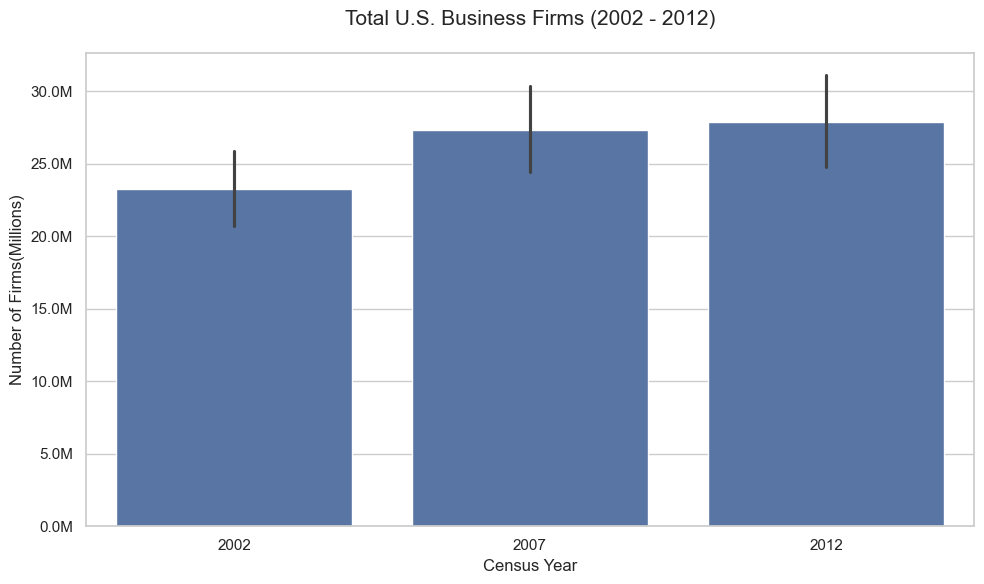

In [24]:
from matplotlib import ticker
df_totals = df[
    (df['Gender_Desc'] == 'All firms') &
    (df['Race_Group_Desc'] == 'All firms') &
    (df['Eth_Group_Desc'] == 'All firms') &
    (df['Vet_Group_Desc'] == 'All firms')
].copy()
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_totals,
    x='Year',
    y='Total_Firms',
    estimator=sum
)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

plt.title('Total U.S. Business Firms (2002 - 2012)', fontsize=15, pad=20)
plt.ylabel('Number of Firms(Millions)', fontsize=12)
plt.xlabel('Census Year', fontsize=12)
plt.tight_layout()

plt.show()

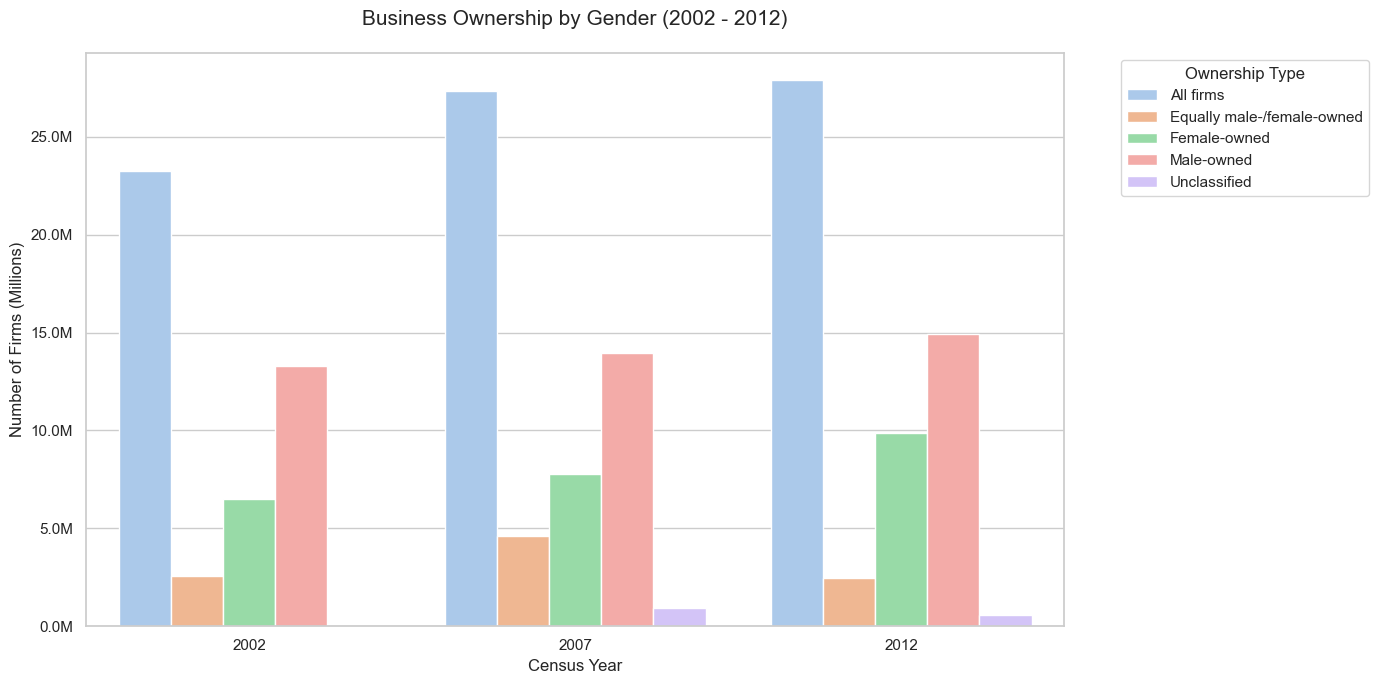

In [25]:



gender_list = ['All firms','Male-owned', 'Female-owned', 'Equally male-/female-owned','Unclassified']

df_gender = df[
    (df['Gender_Desc'].isin(gender_list)) &
    (df['Race_Group_Desc'] == 'All firms') &
    (df['Eth_Group_Desc'] == 'All firms') &
    (df['Vet_Group_Desc'] == 'All firms')
].sort_values('Year').copy()

plt.figure(figsize=(14, 7))

ax = sns.barplot(data=df_gender, x='Year', y='Total_Firms', hue='Gender_Desc',
palette='pastel',estimator=sum,errorbar=None
)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

plt.title('Business Ownership by Gender (2002 - 2012)', fontsize=15, pad=20)
plt.ylabel('Number of Firms (Millions)', fontsize=12)
plt.xlabel('Census Year', fontsize=12)
plt.legend(title='Ownership Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

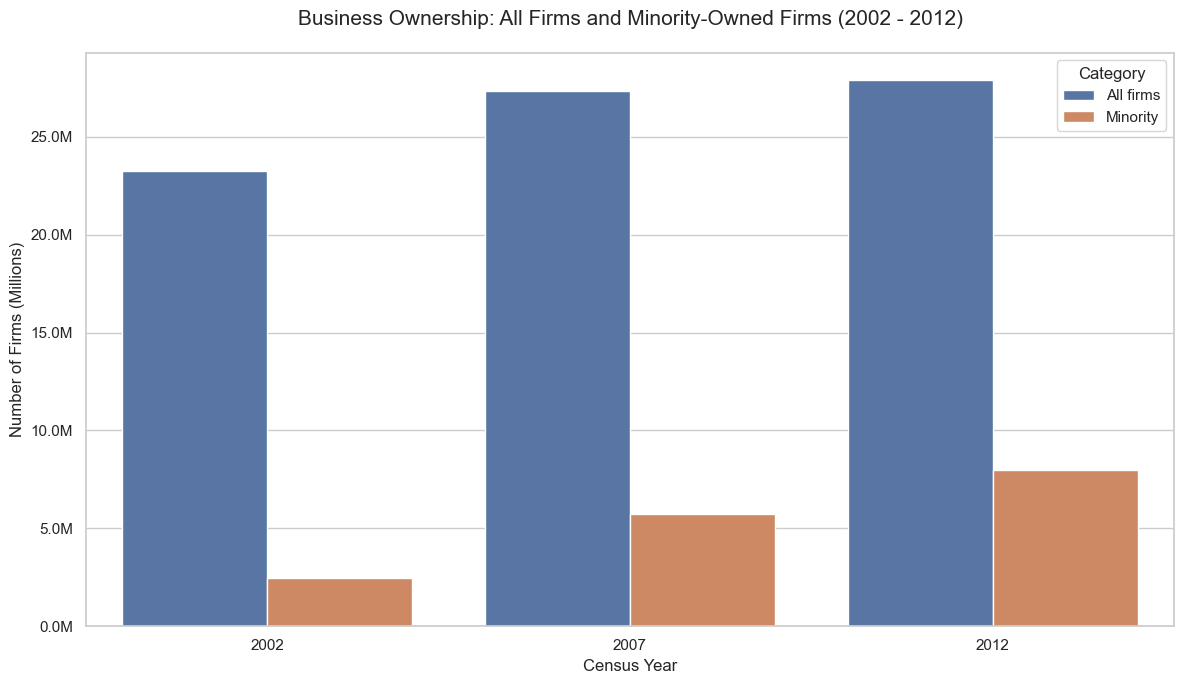

In [26]:
from matplotlib import ticker
import numpy as np

df_macro = df[
    (df['Race_Group_Desc'].isin(['All firms', 'Minority'])) &
    (df['Gender_Desc'] == 'All firms') &
    (df['Eth_Group_Desc'] == 'All firms') &
    (df['Vet_Group_Desc'] == 'All firms')
].sort_values('Year').copy()

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=df_macro,
    x='Year',
    y='Total_Firms',
    hue='Race_Group_Desc',
    estimator=sum,     
    errorbar=None
)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

plt.title('Business Ownership: All Firms and Minority-Owned Firms (2002 - 2012)', fontsize=15, pad=20)
plt.ylabel('Number of Firms (Millions)')
plt.xlabel('Census Year')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

### Fred Data Exploration

In [ ]:
conn = sqlite3.connect(db_fred_path)

query = """
SELECT
    Year,
    AVG(CASE WHEN Series_ID = 'UNRATE'   THEN Yearly_Value END) AS UNRATE,
    AVG(CASE WHEN Series_ID = 'CPIAUCSL' THEN Yearly_Value END) AS CPIAUCSL,
    AVG(CASE WHEN Series_ID = 'FEDFUNDS' THEN Yearly_Value END) AS FEDFUNDS,
    AVG(CASE WHEN Series_ID = 'MPRIME'   THEN Yearly_Value END) AS MPRIME
FROM 
    FRED_OBSERVATION_YEARLY
GROUP BY 
    Year
ORDER BY 
    Year ASC;
"""

# Load into DataFrame - it's already Wide!
fred_df = pd.read_sql_query(query, conn)
conn.close()

fred_df['date'] = pd.to_datetime(fred_df['Year'], format='%Y')
fred_df['Inflation_YoY'] = fred_df['CPIAUCSL'].pct_change(1) * 100

print("Wide DataFrame shape from SQL pivot:", fred_df.shape)
display(fred_df.head())

Wide DataFrame shape from SQL pivot: (28, 7)


,Year,UNRATE,CPIAUCSL,FEDFUNDS,MPRIME,date,Inflation_YoY
0,1987,6.175000,113.616667,6.657500,8.203333,1987-01-01,NaN
1,1988,5.491667,118.275000,7.568333,9.315000,1988-01-01,4.100044
2,1989,5.258333,123.941667,9.216667,10.873333,1989-01-01,4.791094
3,1990,5.616667,130.658333,8.099167,10.009167,1990-01-01,5.419216
4,1991,6.850000,136.166667,5.687500,8.463333,1991-01-01,4.215830


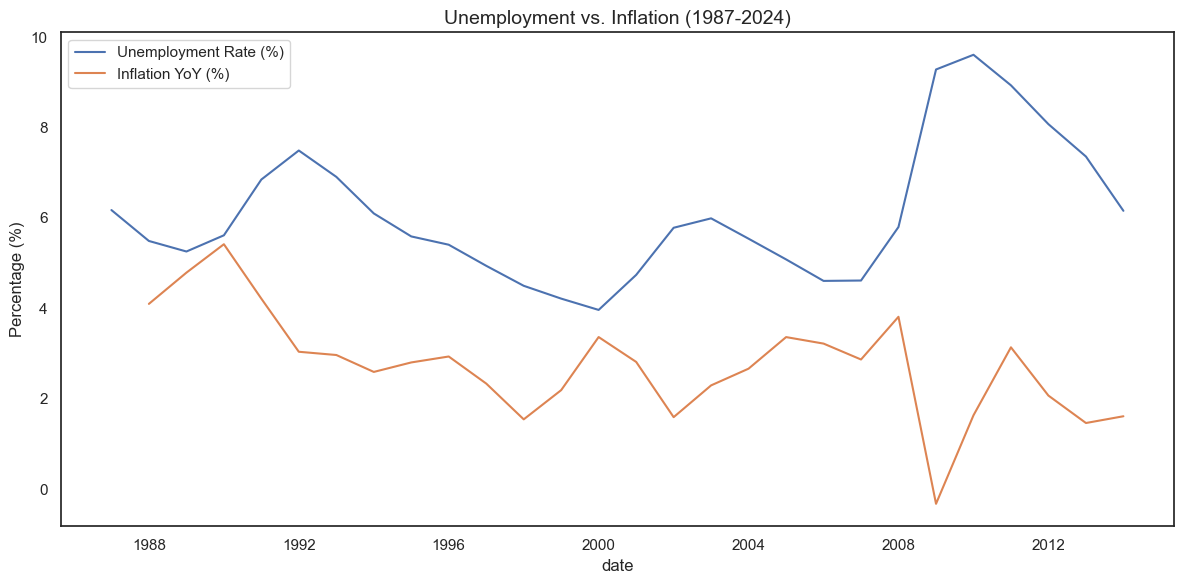

In [28]:

plt.figure(figsize=(12, 6))
sns.set_style("white")

sns.lineplot(data=fred_df, x='date', y='UNRATE', label='Unemployment Rate (%)')
sns.lineplot(data=fred_df, x='date', y='Inflation_YoY', label='Inflation YoY (%)')

plt.title('Unemployment vs. Inflation (1987-2024)', fontsize=14)
plt.ylabel('Percentage (%)')
plt.legend()

plt.tight_layout()
plt.show()

The chart shows an inverse relationship between unemployment and inflation, illustrating several business cycles. You can clearly see the "Great Recession" around 2008, where unemployment spiked toward 10% while inflation plummeted into negative territory. Outside of that crisis, the late 1990s stand out as a period of strong economic performance with low unemployment and stable inflation, providing great environment for the business growth.

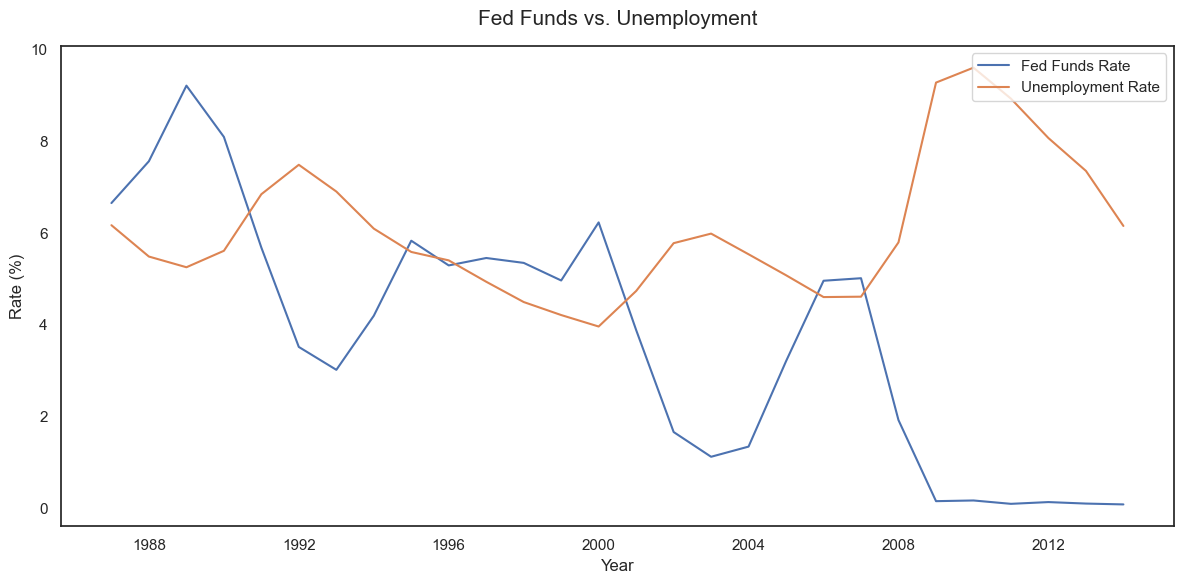

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(fred_df['date'], fred_df['FEDFUNDS'], label='Fed Funds Rate')
ax.plot(fred_df['date'], fred_df['UNRATE'], label='Unemployment Rate')
ax.set_xlabel('Year')
ax.set_ylabel('Rate (%)')
plt.title('Fed Funds vs. Unemployment', fontsize=15, pad=15)
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

The relationship between the Fed Funds Rate and Unemployment illustrates a proactive monetary policy: as unemployment spikes, the Federal Reserve aggressively cuts interest rates toward zero to stimulate the economy. Conversely, when the labor market is strong and unemployment is low (such as in the late 1980s or late 1990s), rates are often kept higher to prevent overheating.

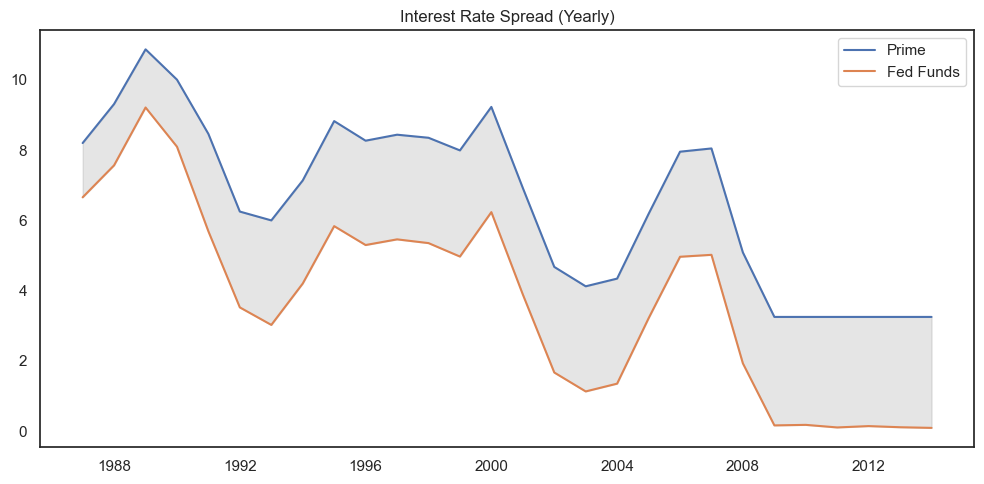

In [31]:

plt.figure(figsize=(10, 5))

plt.plot(fred_df['date'], fred_df['MPRIME'], label='Prime')
plt.plot(fred_df['date'], fred_df['FEDFUNDS'], label='Fed Funds')

plt.fill_between(fred_df['date'], fred_df['FEDFUNDS'], fred_df['MPRIME'], color='grey', alpha=0.2)

plt.title('Interest Rate Spread (Yearly)')
plt.legend()
plt.tight_layout()
plt.show()

The spread between the Bank Prime Rate and the Federal Funds Rate remained consistent at 3% margin throughout most of the 1987–2014 period. Even when the Federal Reserve slashed rates to near-zero following the 2008 financial crisis, the Prime Rate bottomed out around 3.25%, maintaining that constant gap despite extreme economic stress.